# Lab Day 1 — Neural network training experiments (Forest CoverType)

Notebook tự clone repo, đọc danh sách thí nghiệm từ `code/experiments.yaml`, chuẩn bị thư mục `submission_<MSSV>/`, chạy toàn bộ Part 0–4 và ghi
`figures/`, `results/`, `experiments.xlsx`, `predictions_eval.csv`, `eval_result.json`.

**Cách dùng:** sửa ô **CONFIG** bên dưới (ít nhất là `MSSV`) → *Runtime → Run all* (Colab) / *Restart & Run All*.
Trên Colab nên chọn GPU (*Runtime → Change runtime type → T4 GPU*). Các ô **Nhận xét / Dự đoán** là phần tự viết.

In [1]:
# ===================== CONFIG — chỉnh ở đây rồi Run All =====================
MSSV          = "2A202602723"            # mã số sinh viên -> thư mục submission_<MSSV>/
REPO_URL      = "https://github.com/Le-Anh-Duy/K4-Track4-Day1-Neuralnetwork.git"
BRANCH        = "main"
CLONE_PARENT  = None                  # None: /content (Colab), /kaggle/working (Kaggle), thư mục hiện tại (máy local)
USE_DRIVE     = False                 # Colab: đặt submission_<MSSV>/ trên Google Drive (an toàn khi bị ngắt kết nối)
DRIVE_DIR     = "/content/drive/MyDrive/K4-Track4-Day1"

CONFIG_FILE   = "experiments.yaml"    # danh sách thí nghiệm (trong code/ của repo)

SKIP_EXISTING = True                  # đã có results/<exp_id>.json (+ checkpoint) cùng cfg -> nạp lại, không chạy lại
QUICK         = False                 # True: chạy thử cả kế hoạch với 2 epoch vào submission_<MSSV>_quick/ (chỉ để kiểm tra pipeline)

In [2]:
# ===== Clone repo, tạo thư mục nộp, chọn device =====
import os, sys, json, time, shutil, subprocess, math
from pathlib import Path

IN_COLAB, IN_KAGGLE = "google.colab" in sys.modules, os.path.exists("/kaggle/working")

def find_repo(start):
    p = Path(start).resolve()
    for q in [p, *p.parents]:
        if (q / "scripts" / "split_data.py").exists() and (q / "data" / "covtype.csv.gz").exists():
            return q
    return None

REPO_ROOT = find_repo(os.getcwd())
if REPO_ROOT is None:
    parent = Path(CLONE_PARENT or ("/content" if IN_COLAB else "/kaggle/working" if IN_KAGGLE else os.getcwd()))
    REPO_ROOT = parent / Path(REPO_URL).stem
    if (REPO_ROOT / ".git").exists():
        subprocess.run(["git", "-C", str(REPO_ROOT), "pull", "--ff-only"], check=False)
    else:
        subprocess.run(["git", "clone", "--depth", "1", "-b", BRANCH, REPO_URL, str(REPO_ROOT)], check=True)
print("REPO_ROOT =", REPO_ROOT)

if USE_DRIVE and IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    SUB_PARENT = Path(DRIVE_DIR)
else:
    SUB_PARENT = REPO_ROOT
SUB_DIR  = SUB_PARENT / (f"submission_{MSSV}" + ("_quick" if QUICK else ""))
CODE_DIR = SUB_DIR / "code"
CODE_DIR.mkdir(parents=True, exist_ok=True)

# Chép code/ của repo vào submission_<MSSV>/code/ (trừ khi notebook đang chạy ngay trong thư mục đó)
if Path(os.getcwd()).resolve() != CODE_DIR.resolve():
    for f in [*(REPO_ROOT / "code").glob("*.py"), *(REPO_ROOT / "code").glob("*.yaml")]:
        shutil.copy2(f, CODE_DIR / f.name)
    if not (CODE_DIR / "lab.ipynb").exists():
        shutil.copy2(REPO_ROOT / "code" / "lab.ipynb", CODE_DIR / "lab.ipynb")
os.chdir(CODE_DIR)
sys.path.insert(0, str(CODE_DIR))

OUT_DIR  = str(SUB_DIR)                                   # = ".." khi đứng trong submission_<MSSV>/code
FIG_DIR, RES_DIR = f"{OUT_DIR}/figures", f"{OUT_DIR}/results"
CKPT_DIR = REPO_ROOT / "checkpoints" / SUB_DIR.name       # trọng số best_state, nằm NGOÀI thư mục nộp
for d in (FIG_DIR, RES_DIR, CKPT_DIR):
    os.makedirs(d, exist_ok=True)
print("SUB_DIR  =", SUB_DIR)

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from IPython.display import display, Image
display_img = lambda p: display(Image(p))

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("torch", torch.__version__, "| device:", device, "|", torch.cuda.get_device_name(0) if device == "cuda" else "")
if device == "mps":
    device = "cpu"  # torch.Generator / bincount trên mps còn hạn chế; mạng nhỏ chạy CPU cũng ổn

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval, compute_loss
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx
from runner import Runner, load_plan
set_seed(0)

REPO_ROOT = /content/K4-Track4-Day1-Neuralnetwork
SUB_DIR  = /content/K4-Track4-Day1-Neuralnetwork/submission_2A202602723
torch 2.11.0+cu130 | device: cuda | Tesla T4


## Part 0 — Dữ liệu
Chia sẵn bằng metadata (`scripts/split_data.py`) → tách validation 20% từ train (phân tầng, seed 42)
→ chuẩn hoá 10 cột số bằng thống kê của phần train còn lại → đưa toàn bộ lên device.

In [3]:
if not (REPO_ROOT / "data/processed/train.npz").exists():
    subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True,
                   env={**os.environ, "PYTHONIOENCODING": "utf-8"})

data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")
assert len(data["X_tr"]) == 371_847 and len(data["X_val"]) == 92_962 and len(data["X_eval"]) == 116_203

dist = pd.DataFrame({name: np.bincount(data[k].cpu().numpy(), minlength=7) for name, k in
                     [("train", "y_tr"), ("val", "y_val"), ("eval", "y_eval")]})
display(pd.concat([dist, (100 * dist / dist.sum()).round(3).add_suffix(" %")], axis=1))

num = data["X_tr"][:, :10]
print("mean 10 cột số trên X_tr:", num.mean(0).cpu().numpy().round(4))
print("std  10 cột số trên X_tr:", num.std(0).cpu().numpy().round(4))
print("mean 10 cột số trên X_val (chỉ để đối chiếu, không dùng để chuẩn hoá):", data["X_val"][:, :10].mean(0).cpu().numpy().round(3))

train full: 464,809 -> X_tr (371847, 54), X_val (92962, 54); X_eval (116203, 54)
'luôn đoán lớp đa số' (lớp 1) trên val: acc = 0.4876


,train,val,eval,train %,val %,eval %
0,135578,33894,42368,36.461,36.460,36.460
1,181312,45328,56661,48.760,48.760,48.760
2,22882,5721,7151,6.154,6.154,6.154
3,1759,439,549,0.473,0.472,0.472
4,6075,1519,1899,1.634,1.634,1.634
5,11115,2779,3473,2.989,2.989,2.989
6,13126,3282,4102,3.530,3.530,3.530


mean 10 cột số trên X_tr: [-0. -0.  0.  0.  0.  0. -0. -0. -0.  0.]
std  10 cột số trên X_tr: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
mean 10 cột số trên X_val (chỉ để đối chiếu, không dùng để chuẩn hoá): [ 0.002  0.002 -0.002  0.    -0.     0.006 -0.004  0.002  0.005  0.004]


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
`M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model, khởi tạo He.

In [4]:
# 1) Model + số tham số
set_seed(1)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
assert count_params(model) == EXPECTED_PARAMS[(256, 128)] == 47_879
print(model)
print("số tham số:", count_params(model))
for hid in EXPECTED_PARAMS:  # kiểm tra luôn M-wide, M-deep
    assert count_params(MLP(hidden=hid)) == EXPECTED_PARAMS[hid], hid

# 2) Shape qua từng lớp với một lô ngẫu nhiên (8, 54)
h = torch.randn(8, 54, device=device)
for layer in model.net:
    h = layer(h)
    print(f"{layer.__class__.__name__:8s} -> {tuple(h.shape)}")
assert model(torch.randn(8, 54, device=device)).shape == (8, 7)

# 3) Loss bước 0 trên val (eval mode)
step0 = evaluate(model, data["X_val"], data["y_val"])
print(f"loss bước 0 trên val = {step0['loss']:.4f}  |  ln 7 = {math.log(7):.4f}  |  acc = {step0['acc']:.4f}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)
số tham số: 47879
Linear   -> (8, 256)
ReLU     -> (8, 256)
Linear   -> (8, 128)
ReLU     -> (8, 128)
Linear   -> (8, 7)
loss bước 0 trên val = 2.2691  |  ln 7 = 1.9459  |  acc = 0.0283


loss sau 500 bước = 8.58e-07 | accuracy trên 20 mẫu = 1.00


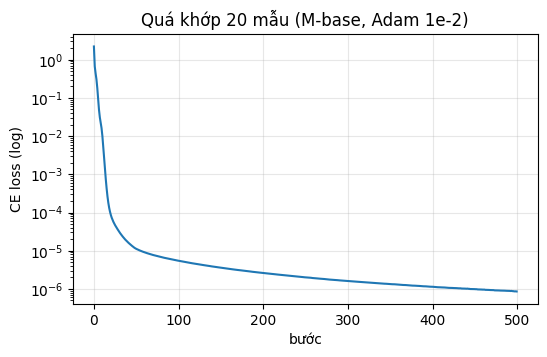

net.0.weight   shape (256, 54)    grad norm = 5.0705e-01
net.0.bias     shape (256,)       grad norm = 3.4224e-01
net.2.weight   shape (128, 256)   grad norm = 2.0212e+00
net.2.bias     shape (128,)       grad norm = 4.4387e-01
net.4.weight   shape (7, 128)     grad norm = 1.9605e+00
net.4.bias     shape (7,)         grad norm = 5.7246e-01


In [5]:
# 4) Quá khớp 20 mẫu (không dropout, Adam lr 1e-2, 500 bước) -> loss phải về gần 0
set_seed(1)
tiny = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
idx = torch.randperm(len(data["X_tr"]), device=device)[:20]
xb20, yb20 = data["X_tr"][idx], data["y_tr"][idx]
opt = torch.optim.Adam(tiny.parameters(), lr=1e-2)
losses = []
for step in range(500):
    tiny.train()
    loss = compute_loss(tiny(xb20), yb20, "ce")
    opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
    losses.append(loss.item())
acc20 = (predict(tiny, xb20) == yb20).float().mean().item()
print(f"loss sau 500 bước = {losses[-1]:.2e} | accuracy trên 20 mẫu = {acc20:.2f}")
assert losses[-1] < 1e-2 and acc20 == 1.0

plt.figure(figsize=(6, 3.5))
plt.semilogy(losses); plt.xlabel("bước"); plt.ylabel("CE loss (log)"); plt.title("Quá khớp 20 mẫu (M-base, Adam 1e-2)")
plt.grid(alpha=0.3); plt.show()

# 5) Gradient có chảy tới mọi tham số?
model.train(); model.zero_grad()
compute_loss(model(data["X_tr"][:512]), data["y_tr"][:512], "ce").backward()
for name, p in model.named_parameters():
    print(f"{name:14s} shape {str(tuple(p.shape)):12s} grad norm = {p.grad.norm().item():.4e}")
    assert p.grad is not None and p.grad.norm().item() > 0, name

**Nhận xét Part 1 (tự viết):** loss bước 0 đo được = ___, so với ln 7 = 1.946 vì sao ...; quá khớp 20 mẫu: ...; gradient: ...

## Part 2 + 3 — Chạy toàn bộ kế hoạch thí nghiệm (một lượt)
Danh sách thí nghiệm nằm trong **`code/experiments.yaml`** (sửa file đó trên repo để thêm/bớt thí nghiệm). Ô dưới chạy theo thứ tự:
1. **Tìm lr baseline** (SGD+momentum, nhiều lr, seed 1) → `BASE_LR` = lr có val macro-F1 cao nhất (chỉ dùng val).
2. **Baseline** với nhiều seed → độ nhiễu 2σ của val macro-F1; `CLIP_C` = trung vị grad_norm của `base-s1`.
3. **Các thí nghiệm** của 7 chủ đề, mỗi thí nghiệm đổi một yếu tố so với baseline (cùng split, 20 epoch, seed 1).
4. **Cấu hình cuối** chọn bằng val theo quy tắc trong `final:` của file YAML.

Mỗi lần chạy lưu `results/<exp_id>.json`, `figures/<exp_id>.png` và checkpoint `best_state` (ngoài thư mục nộp).
`run_experiment(cfg, data)` trong `train.py` là hàm huấn luyện duy nhất; `runner.py` chỉ điều phối.

In [6]:
PLAN = load_plan(CODE_DIR / CONFIG_FILE)
runner = Runner(PLAN, data, FIG_DIR, RES_DIR, CKPT_DIR, skip_existing=SKIP_EXISTING,
                epochs_override=2 if QUICK else None)
print(f"{len(PLAN['lr_search']['lrs'])} lr search + {len(PLAN['base_seeds'])} baseline + "
      f"{len(PLAN['experiments'])} thí nghiệm + {len(PLAN['final']['seeds'])} final")
runner.run_all(device)

RESULTS, base_ids, final_ids, NOISE = runner.results, runner.base_ids, runner.final_ids, runner.noise
BASE_LR, CLIP_C = runner.ctx["BASE_LR"], runner.ctx["CLIP_C"]
if runner.skipped:
    print("Bỏ qua:", runner.skipped)

def show(patterns, compare=None):
    df = runner.table(patterns)
    display(df.style.format(precision=4, na_rep="—"))
    for name in ([compare] if isinstance(compare, str) else compare or []):
        p = f"{FIG_DIR}/compare_{name}.png"
        if os.path.exists(p):
            display_img(p)
    return df

4 lr search + 3 baseline + 30 thí nghiệm + 2 final
=== 1. Tìm lr baseline (SGD+momentum) bằng val ===
[lr-sgdm-0.003]  26.8s | step0 2.269 | best ep 20 | val_loss 0.4198 | val_acc 0.8250 | val_F1 0.6647 | diverged N
[lr-sgdm-0.01]  29.8s | step0 2.269 | best ep 20 | val_loss 0.3110 | val_acc 0.8747 | val_F1 0.7613 | diverged N
[lr-sgdm-0.03]  28.0s | step0 2.269 | best ep 20 | val_loss 0.2660 | val_acc 0.8921 | val_F1 0.8170 | diverged N
[lr-sgdm-0.1]  27.0s | step0 2.269 | best ep 18 | val_loss 0.2379 | val_acc 0.9054 | val_F1 0.8390 | diverged N
=> BASE_LR = 0.1 (từ lr-sgdm-0.1)
=== 2. Baseline nhiều seed -> độ nhiễu ===
[base-s1]  26.9s | step0 2.269 | best ep 18 | val_loss 0.2379 | val_acc 0.9054 | val_F1 0.8390 | diverged N
[base-s2]  26.4s | step0 1.978 | best ep 19 | val_loss 0.2279 | val_acc 0.9100 | val_F1 0.8601 | diverged N
[base-s3]  26.0s | step0 1.901 | best ep 19 | val_loss 0.2277 | val_acc 0.9091 | val_F1 0.8614 | diverged N
=> val_macro_f1 baseline = 0.8535 ± 0.0126, 2

### 2a. Chọn lr baseline bằng val

,optimizer,lr,wd,batch,hidden,dropout,clip,prec,init,loss,sched,step0,best_ep,best_val_loss,final_train,final_val,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1 vs base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,,,
lr-sgdm-0.003,sgd_momentum,0.0030,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,20,0.4198,0.4097,0.4198,0.8250,0.6647,1.2818,175.5786,N,-0.1888,Có
lr-sgdm-0.01,sgd_momentum,0.0100,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,20,0.3110,0.2967,0.3110,0.8747,0.7613,1.4334,175.5786,N,-0.0923,Có
lr-sgdm-0.03,sgd_momentum,0.0300,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,20,0.2660,0.2463,0.2660,0.8921,0.8170,1.3494,175.5786,N,-0.0366,Có
lr-sgdm-0.1,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,18,0.2379,0.2164,0.2426,0.9054,0.8390,1.3042,175.5786,N,-0.0145,Không


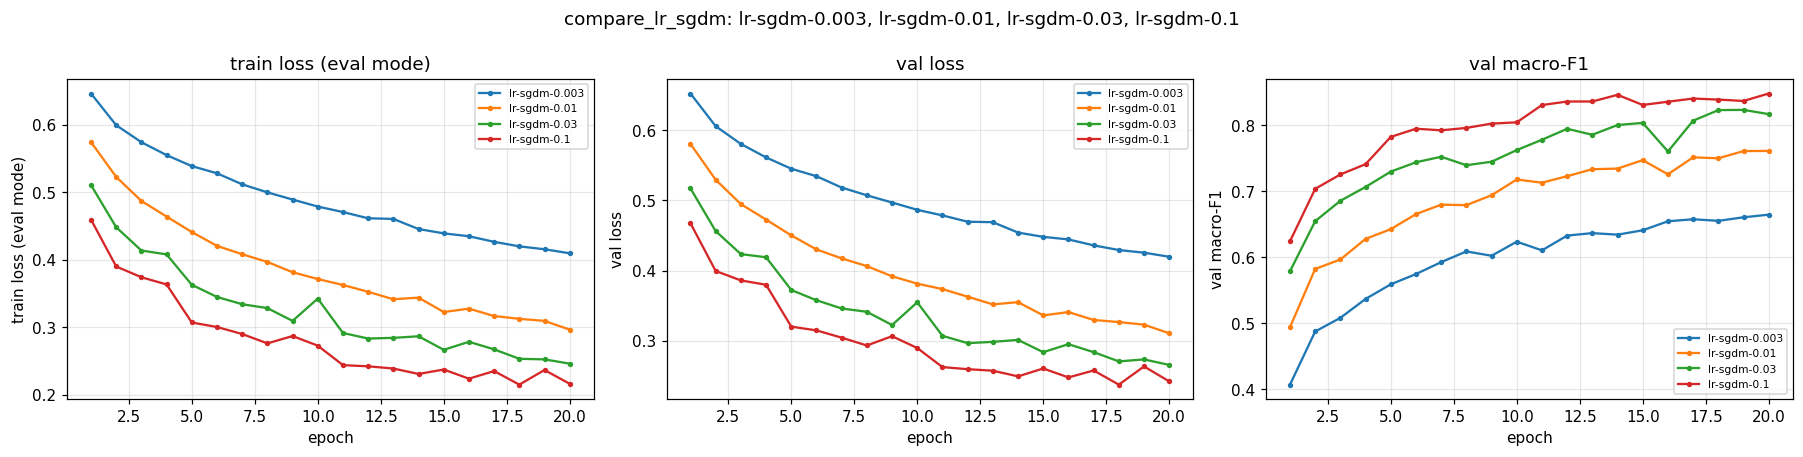

BASE_LR = 0.1


In [7]:
show(["lr-sgdm-*"], "lr_sgdm")
print("BASE_LR =", BASE_LR)

### 2b. Baseline với nhiều seed → độ nhiễu

val_macro_f1 = 0.8535 ± 0.0126 (std mẫu, n=3) -> ngưỡng nhiễu 2σ = 0.0251
val_acc      = 0.9082 ± 0.0024   (mốc 'đoán đa số' = 0.4876)


,optimizer,lr,wd,batch,hidden,dropout,clip,prec,init,loss,sched,step0,best_ep,best_val_loss,final_train,final_val,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1 vs base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,18,0.2379,0.2164,0.2426,0.9054,0.8390,1.2935,175.5786,N,-0.0145,Không
base-s2,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,1.9782,19,0.2279,0.2067,0.2325,0.9100,0.8601,1.2747,175.5786,N,0.0065,Không
base-s3,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,1.9005,19,0.2277,0.2135,0.2375,0.9091,0.8614,1.2532,175.5786,N,0.0079,Không


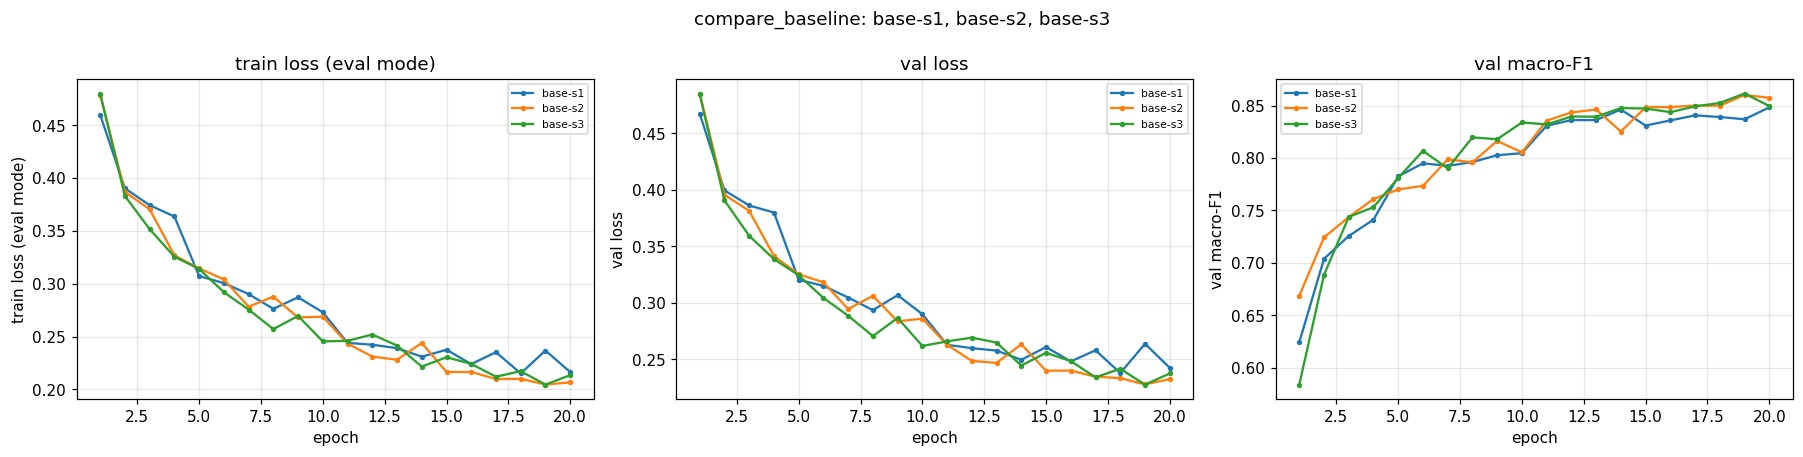

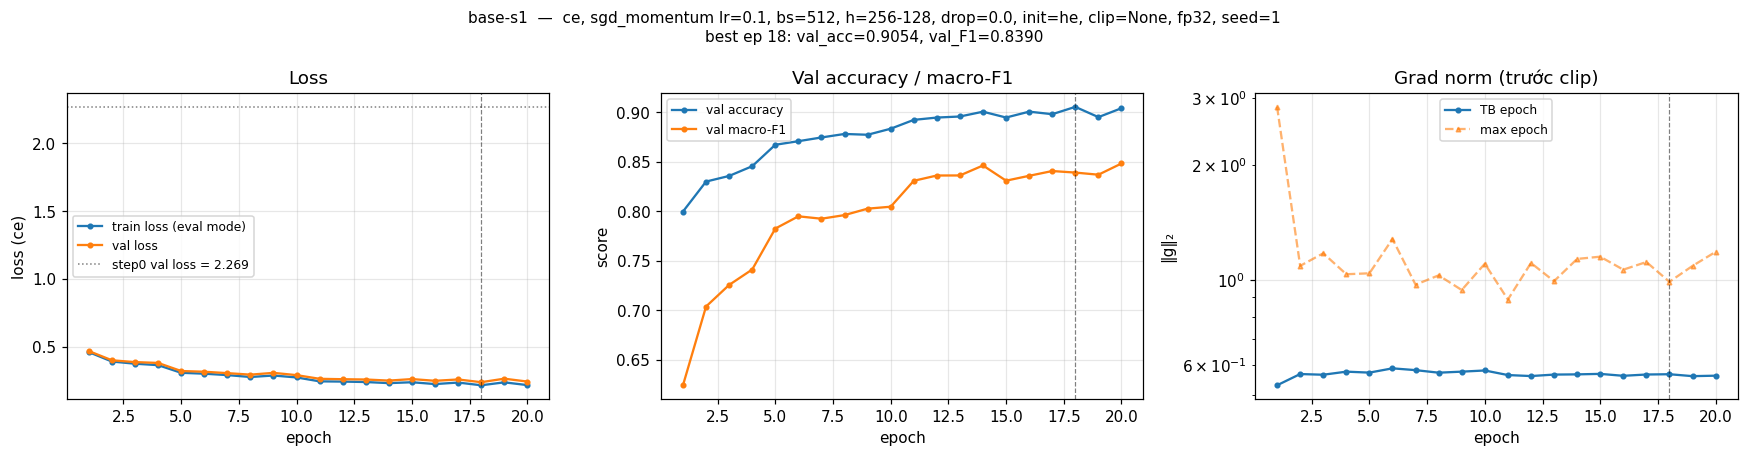

In [8]:
f1s = np.array([RESULTS[e]["summary"]["val_macro_f1"] for e in base_ids])
accs = np.array([RESULTS[e]["summary"]["val_acc"] for e in base_ids])
print(f"val_macro_f1 = {f1s.mean():.4f} ± {f1s.std(ddof=1):.4f} (std mẫu, n={len(f1s)}) -> ngưỡng nhiễu 2σ = {NOISE['two_sigma']:.4f}")
print(f"val_acc      = {accs.mean():.4f} ± {accs.std(ddof=1):.4f}   (mốc 'đoán đa số' = 0.4876)")
show(base_ids, "baseline")
display_img(f"{FIG_DIR}/base-s1.png")

**Nhận xét baseline (tự viết):** hình dạng đường cong (còn giảm? bắt đầu quá khớp?), val_acc so với mốc "đoán đa số" 0.4876, độ nhiễu giữa các seed ...

## Part 3 — Kết quả từng chủ đề
So sánh với `base-s1` và với ngưỡng nhiễu 2σ của val macro-F1 (cột `vượt 2σ?`).

### Chủ đề 1 — Hàm mất mát: CE vs MSE (trên one-hot)
MSE = trung bình bình phương trên mọi phần tử `(B × 7)` giữa logits và one-hot (như `nn.MSELoss`, không có hệ số 1/2).
Chạy ở lr baseline và lr ×10. Không so loss trực tiếp (khác thang đo); so accuracy / macro-F1 / tốc độ hội tụ.

**Dự đoán trước (tự viết):** ...

,optimizer,lr,wd,batch,hidden,dropout,clip,prec,init,loss,sched,step0,best_ep,best_val_loss,final_train,final_val,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1 vs base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,18,0.2379,0.2164,0.2426,0.9054,0.8390,1.2935,175.5786,N,-0.0145,Không
loss-mse,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,—,fp32,he,mse,—,0.6359,20,0.0293,0.0283,0.0293,0.8705,0.7277,1.4131,175.5786,N,-0.1258,Có
loss-mse-lrx10,sgd_momentum,1.0000,0.0000,512,256-128,0.0000,—,fp32,he,mse,—,0.6359,20,0.0454,0.0450,0.0454,0.7956,0.5991,1.3951,175.5786,N,-0.2544,Có


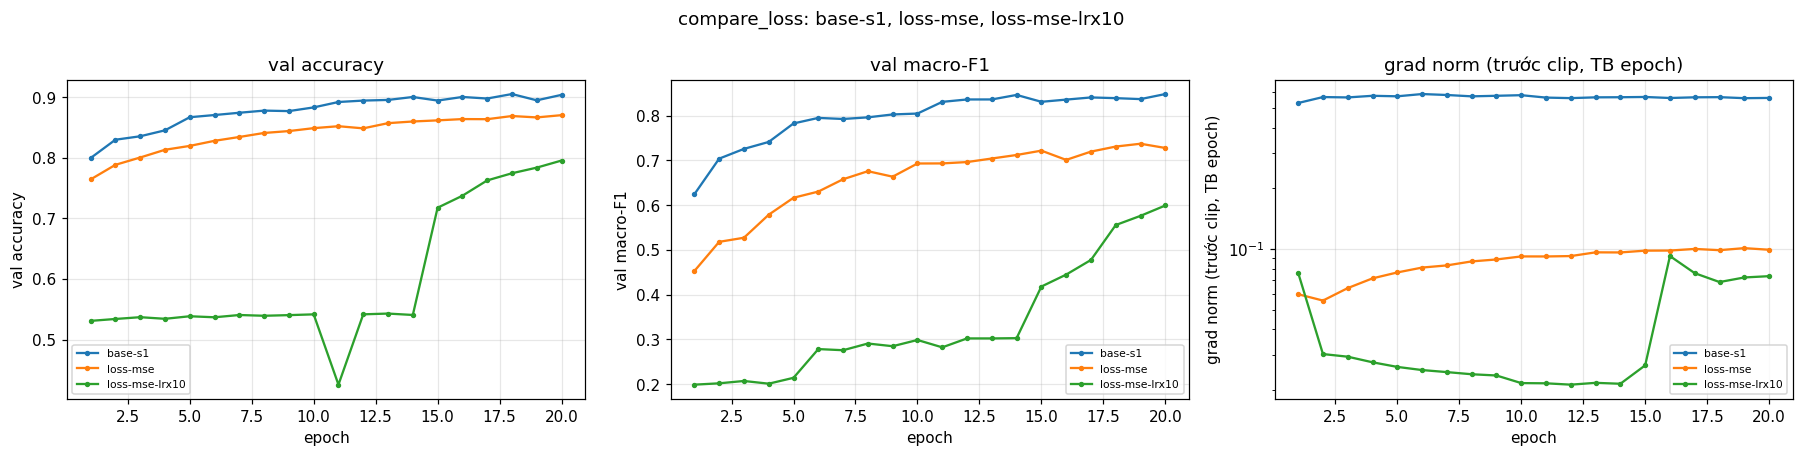

,optimizer,lr,wd,batch,hidden,dropout,clip,prec,init,loss,...,best_val_loss,final_train,final_val,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1 vs base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.1,0.0,512,256-128,0.0,None,fp32,he,ce,...,0.237924,0.216433,0.242554,0.905381,0.839036,1.293512,175.578613,N,-0.014475,Không
loss-mse,sgd_momentum,0.1,0.0,512,256-128,0.0,None,fp32,he,mse,...,0.029331,0.028252,0.029331,0.870506,0.727665,1.413122,175.578613,N,-0.125845,Có
loss-mse-lrx10,sgd_momentum,1.0,0.0,512,256-128,0.0,None,fp32,he,mse,...,0.045421,0.044962,0.045421,0.795615,0.599100,1.395129,175.578613,N,-0.254411,Có


In [9]:
show(["base-s1", "loss-*"], "loss")

**Đối chiếu (tự viết):** ...

### Chủ đề 2 — Bộ tối ưu hoá
SGD, SGD+momentum (lưới lr ở 2a), Adam, AdamW (`weight_decay=0.01`), mỗi bộ ≥ 3 lr; so ở **lr tốt nhất của mỗi bộ**.
Tham số: momentum 0.9; Adam/AdamW `betas=(0.9, 0.999)`, `eps=1e-8`.

**Dự đoán trước (tự viết):** ...

,optimizer,lr,wd,batch,hidden,dropout,clip,prec,init,loss,sched,step0,best_ep,best_val_loss,final_train,final_val,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1 vs base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,,,
lr-sgdm-0.003,sgd_momentum,0.0030,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,20,0.4198,0.4097,0.4198,0.8250,0.6647,1.2818,175.5786,N,-0.1888,Có
lr-sgdm-0.01,sgd_momentum,0.0100,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,20,0.3110,0.2967,0.3110,0.8747,0.7613,1.4334,175.5786,N,-0.0923,Có
lr-sgdm-0.03,sgd_momentum,0.0300,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,20,0.2660,0.2463,0.2660,0.8921,0.8170,1.3494,175.5786,N,-0.0366,Có
lr-sgdm-0.1,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,18,0.2379,0.2164,0.2426,0.9054,0.8390,1.3042,175.5786,N,-0.0145,Không
opt-sgd-lr0.03,sgd,0.0300,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,19,0.4349,0.4383,0.4479,0.8142,0.6586,1.2255,175.3955,N,-0.1949,Có
opt-sgd-lr0.1,sgd,0.1000,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,18,0.3475,0.4293,0.4437,0.8580,0.7551,1.2436,175.3955,N,-0.0985,Có
opt-sgd-lr0.3,sgd,0.3000,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,18,0.2803,0.3150,0.3327,0.8871,0.8163,1.2442,175.3955,N,-0.0372,Có
opt-adam-lr3e-4,adam,0.0003,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,20,0.3135,0.2985,0.3135,0.8727,0.7877,1.4261,175.7617,N,-0.0658,Có
opt-adam-lr1e-3,adam,0.0010,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,19,0.2494,0.2305,0.2529,0.8993,0.8456,1.4140,175.7617,N,-0.0080,Không


lr tốt nhất của mỗi bộ tối ưu (theo val macro-F1):


,optimizer,lr,wd,batch,hidden,dropout,clip,prec,init,loss,sched,step0,best_ep,best_val_loss,final_train,final_val,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1 vs base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,,,
lr-sgdm-0.1,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,18,0.2379,0.2164,0.2426,0.9054,0.8390,1.3042,175.5786,N,-0.0145,Không
opt-sgd-lr0.3,sgd,0.3000,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,18,0.2803,0.3150,0.3327,0.8871,0.8163,1.2442,175.3955,N,-0.0372,Có
opt-adam-lr3e-3,adam,0.0030,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,19,0.2145,0.1859,0.2160,0.9153,0.8677,1.4033,175.7617,N,0.0142,Không
opt-adamw-lr3e-3,adamw,0.0030,0.0100,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,18,0.2161,0.1951,0.2204,0.9130,0.8646,1.4457,175.7617,N,0.0111,Không


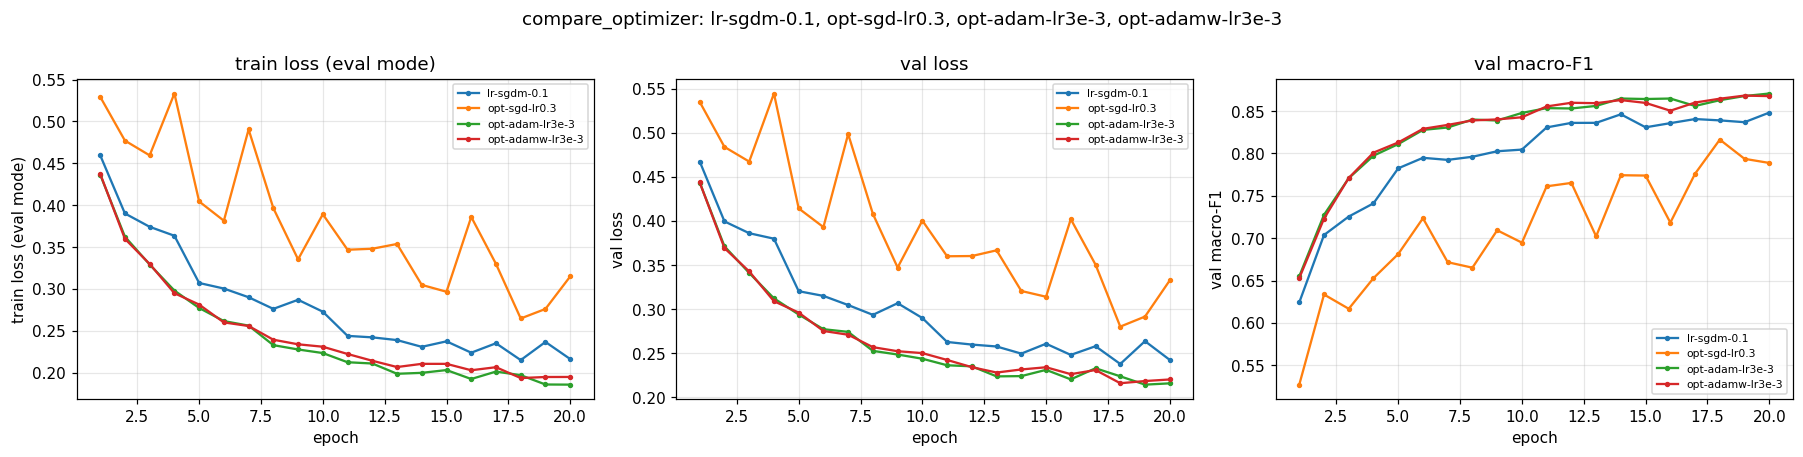

,optimizer,lr,wd,batch,hidden,dropout,clip,prec,init,loss,...,best_val_loss,final_train,final_val,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1 vs base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,
lr-sgdm-0.1,sgd_momentum,0.100,0.00,512,256-128,0.0,None,fp32,he,ce,...,0.237924,0.216433,0.242554,0.905381,0.839036,1.304169,175.578613,N,-0.014475,Không
opt-sgd-lr0.3,sgd,0.300,0.00,512,256-128,0.0,None,fp32,he,ce,...,0.280293,0.314992,0.332651,0.887147,0.816342,1.244155,175.395508,N,-0.037169,Có
opt-adam-lr3e-3,adam,0.003,0.00,512,256-128,0.0,None,fp32,he,ce,...,0.214496,0.185885,0.215953,0.915288,0.867747,1.403306,175.761719,N,0.014236,Không
opt-adamw-lr3e-3,adamw,0.003,0.01,512,256-128,0.0,None,fp32,he,ce,...,0.216100,0.195056,0.220358,0.913029,0.864607,1.445708,175.761719,N,0.011097,Không


In [10]:
show(["lr-sgdm-*", "opt-*"])
print("lr tốt nhất của mỗi bộ tối ưu (theo val macro-F1):")
show(["best:lr-sgdm-*", "best:opt-sgd-*", "best:opt-adam-*", "best:opt-adamw-*"], "optimizer")

**Đối chiếu (tự viết):** ...

### Chủ đề 3 — Hyper-parameter
Batch 128 / 2048 (cùng lr → số bước cập nhật khác nhau), batch 2048 + lr ×4 (quy tắc tăng lr theo lô — đổi 2 yếu tố, có ghi rõ),
`M-wide`, `M-deep`, weight decay 5e-4, cosine lr schedule.

**Dự đoán trước (tự viết):** ...

,optimizer,lr,wd,batch,hidden,dropout,clip,prec,init,loss,sched,step0,best_ep,best_val_loss,final_train,final_val,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1 vs base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,18,0.2379,0.2164,0.2426,0.9054,0.8390,1.2935,175.5786,N,-0.0145,Không
hp-bs128,sgd_momentum,0.1000,0.0000,128,256-128,0.0000,—,fp32,he,ce,—,2.2691,20,0.2190,0.1925,0.2190,0.9130,0.8561,5.1113,175.5479,N,0.0026,Không
hp-bs2048,sgd_momentum,0.1000,0.0000,2048,256-128,0.0000,—,fp32,he,ce,—,2.2691,18,0.2810,0.2741,0.2910,0.8852,0.7970,0.3320,175.8247,N,-0.0565,Có
hp-bs2048-lrx4,sgd_momentum,0.4000,0.0000,2048,256-128,0.0000,—,fp32,he,ce,—,2.2691,20,0.2334,0.2126,0.2334,0.9063,0.8458,0.3440,175.8247,N,-0.0078,Không
hp-wide,sgd_momentum,0.1000,0.0000,512,512-256,0.0000,—,fp32,he,ce,—,1.9182,20,0.2040,0.1729,0.2040,0.9197,0.8735,1.2935,191.6436,N,0.0200,Không
hp-deep,sgd_momentum,0.1000,0.0000,512,256-128-64,0.0000,—,fp32,he,ce,—,1.9099,19,0.2020,0.1776,0.2065,0.9200,0.8648,1.4831,175.6694,N,0.0113,Không
hp-wd5e-4,sgd_momentum,0.1000,0.0005,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,20,0.3339,0.3233,0.3339,0.8652,0.7496,1.3362,175.5786,N,-0.1039,Có
hp-cosine,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,—,fp32,he,ce,cosine,2.2691,20,0.2014,0.1776,0.2014,0.9212,0.8661,1.2981,175.5786,N,0.0126,Không


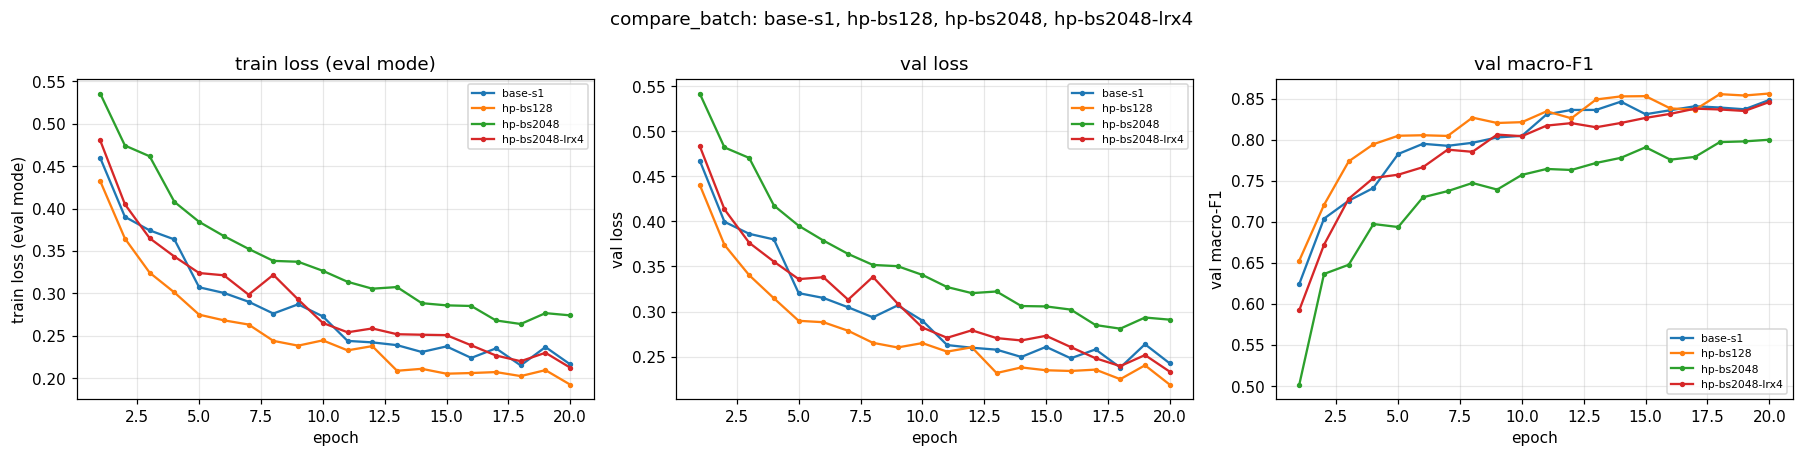

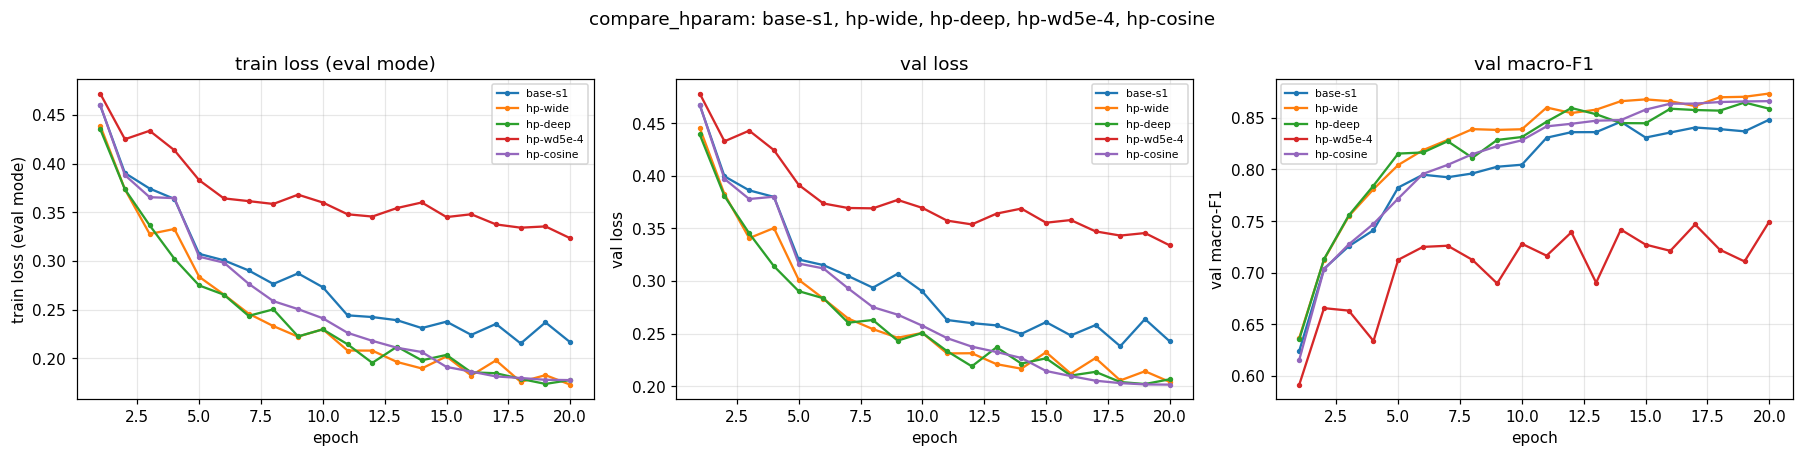

,optimizer,lr,wd,batch,hidden,dropout,clip,prec,init,loss,...,best_val_loss,final_train,final_val,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1 vs base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.1,0.0000,512,256-128,0.0,None,fp32,he,ce,...,0.237924,0.216433,0.242554,0.905381,0.839036,1.293512,175.578613,N,-0.014475,Không
hp-bs128,sgd_momentum,0.1,0.0000,128,256-128,0.0,None,fp32,he,ce,...,0.218990,0.192543,0.218990,0.912954,0.856096,5.111336,175.547852,N,0.002586,Không
hp-bs2048,sgd_momentum,0.1,0.0000,2048,256-128,0.0,None,fp32,he,ce,...,0.281038,0.274138,0.291032,0.885179,0.796963,0.331953,175.824707,N,-0.056548,Có
hp-bs2048-lrx4,sgd_momentum,0.4,0.0000,2048,256-128,0.0,None,fp32,he,ce,...,0.233365,0.212558,0.233365,0.906295,0.845751,0.343954,175.824707,N,-0.007759,Không
hp-wide,sgd_momentum,0.1,0.0000,512,512-256,0.0,None,fp32,he,ce,...,0.204024,0.172892,0.204024,0.919698,0.873525,1.293454,191.643555,N,0.020015,Không
hp-deep,sgd_momentum,0.1,0.0000,512,256-128-64,0.0,None,fp32,he,ce,...,0.201985,0.177597,0.206514,0.920000,0.864787,1.483066,175.669434,N,0.011276,Không
hp-wd5e-4,sgd_momentum,0.1,0.0005,512,256-128,0.0,None,fp32,he,ce,...,0.333853,0.323260,0.333853,0.865235,0.749570,1.336232,175.578613,N,-0.103941,Có
hp-cosine,sgd_momentum,0.1,0.0000,512,256-128,0.0,None,fp32,he,ce,...,0.201411,0.177562,0.201411,0.921247,0.866130,1.298119,175.578613,N,0.012619,Không


In [11]:
show(["base-s1", "hp-*"], ["batch", "hparam"])

**Đối chiếu (tự viết):** ...

### Chủ đề 4 — Dropout
q ∈ {0.1, 0.3, 0.5}, sau ReLU của mỗi lớp ẩn. Train loss đo ở `eval()` nên so được với val loss.

**Dự đoán trước (tự viết):** (gợi ý: baseline có đang quá khớp không? nhìn khoảng cách train–val của `base-s1`)

,optimizer,lr,wd,batch,hidden,dropout,clip,prec,init,loss,sched,step0,best_ep,best_val_loss,final_train,final_val,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1 vs base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,18,0.2379,0.2164,0.2426,0.9054,0.8390,1.2935,175.5786,N,-0.0145,Không
drop-0.1,sgd_momentum,0.1000,0.0000,512,256-128,0.1000,—,fp32,he,ce,—,2.2691,20,0.2477,0.2340,0.2477,0.9005,0.8402,1.4081,175.5786,N,-0.0133,Không
drop-0.3,sgd_momentum,0.1000,0.0000,512,256-128,0.3000,—,fp32,he,ce,—,2.2691,20,0.3151,0.3050,0.3151,0.8728,0.7875,1.4003,175.5786,N,-0.0660,Có
drop-0.5,sgd_momentum,0.1000,0.0000,512,256-128,0.5000,—,fp32,he,ce,—,2.2691,20,0.4005,0.3935,0.4005,0.8289,0.6805,1.4029,175.5786,N,-0.1730,Có


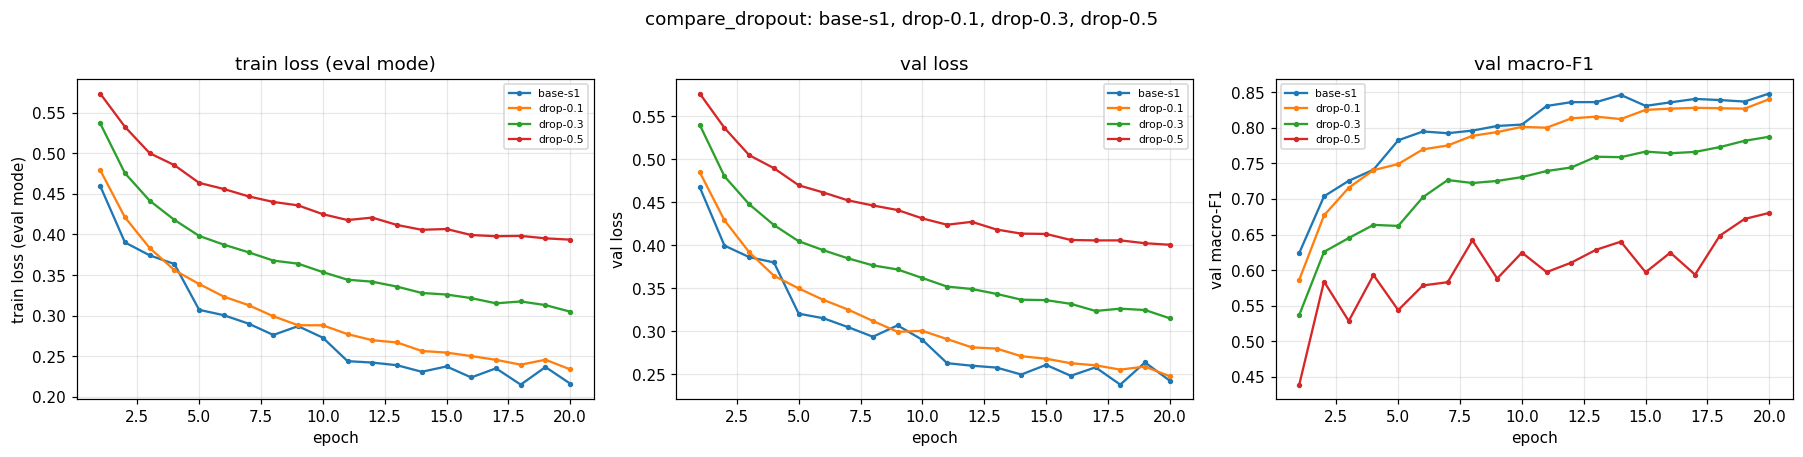

,gap val - train (epoch cuối)
exp_id,
base-s1,0.026121
drop-0.1,0.013717
drop-0.3,0.010129
drop-0.5,0.006988


In [12]:
df = show(["base-s1", "drop-*"], "dropout")
display((df["final_val"] - df["final_train"]).rename("gap val - train (epoch cuối)").to_frame())

**Đối chiếu (tự viết):** ...

### Chủ đề 5 — Gradient clipping
`c = CLIP_C` = trung vị grad norm (TB theo epoch) của `base-s1`, để clipping thực sự kích hoạt ở một phần các bước.
Thí nghiệm phản chứng: lr ×10 **không clip** vs **có clip**.

**Dự đoán trước (tự viết):** ...

grad_norm TB theo epoch của base-s1: [0.53  0.567 0.564 0.575 0.572 0.587 0.58  0.571 0.575 0.579 0.563 0.56
 0.565 0.566 0.567 0.561 0.565 0.566 0.56  0.561]
CLIP_C = 0.57, lr cao = 1


,optimizer,lr,wd,batch,hidden,dropout,clip,prec,init,loss,sched,step0,best_ep,best_val_loss,final_train,final_val,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1 vs base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,18,0.2379,0.2164,0.2426,0.9054,0.8390,1.2935,175.5786,N,-0.0145,Không
clip-c,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,0.5700,fp32,he,ce,—,2.2691,20,0.2402,0.2174,0.2402,0.9043,0.8537,1.3181,175.5786,N,0.0002,Không
clip-c-lrx10,sgd_momentum,1.0000,0.0000,512,256-128,0.0000,0.5700,fp32,he,ce,—,2.2691,14,0.3106,0.2921,0.3163,0.8783,0.8046,1.3083,175.5786,N,-0.0489,Có
noclip-lrx10,sgd_momentum,1.0000,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,19,0.3335,0.3536,0.3708,0.8662,0.7732,1.3176,175.5786,N,-0.0803,Có


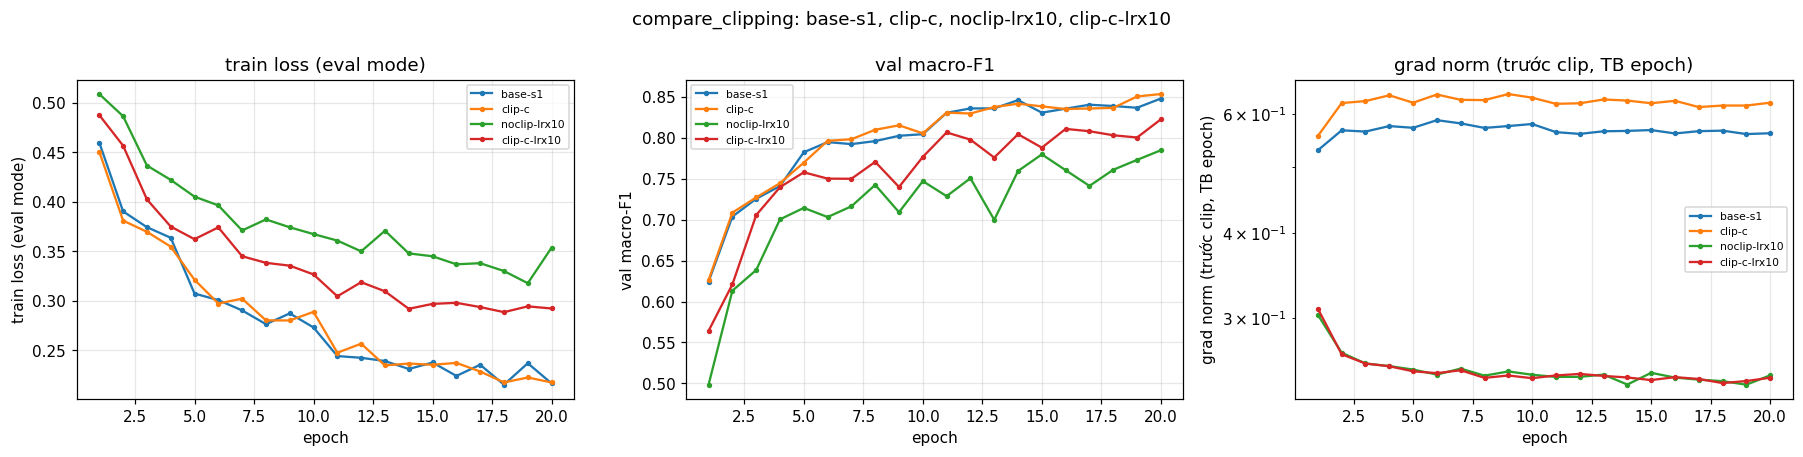

clip-c: tỉ lệ bước bị cắt theo epoch = [0.34 0.57 0.61 0.65 0.6  0.65 0.65 0.64 0.7  0.68 0.65 0.67 0.67 0.65
 0.65 0.65 0.64 0.65 0.65 0.64]
clip-c-lrx10: tỉ lệ bước bị cắt theo epoch = [0.02 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.  ]


In [13]:
print("grad_norm TB theo epoch của base-s1:", np.round(RESULTS["base-s1"]["history"]["grad_norm"], 3))
print(f"CLIP_C = {CLIP_C}, lr cao = {BASE_LR * 10:g}")
show(["base-s1", "clip-*", "noclip-*"], "clipping")
for e in runner.match(["clip-*"]):
    print(f"{e}: tỉ lệ bước bị cắt theo epoch = {np.round(RESULTS[e]['history']['clip_frac'], 2)}")

**Đối chiếu (tự viết):** ...

### Chủ đề 6 — Mixed precision
FP16: `autocast(float16)` + `GradScaler` (luôn `unscale_` trước khi đo/cắt grad norm). BF16: `autocast(bfloat16)`, không GradScaler.
Tham số vẫn FP32. Đo thời gian/epoch, bộ nhớ cực đại, độ chính xác so với FP32.

**Dự đoán trước (tự viết):** ...

bỏ qua: không


,optimizer,lr,wd,batch,hidden,dropout,clip,prec,init,loss,sched,step0,best_ep,best_val_loss,final_train,final_val,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1 vs base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,18,0.2379,0.2164,0.2426,0.9054,0.8390,1.2935,175.5786,N,-0.0145,Không
amp-fp16,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,—,fp16,he,ce,—,2.2691,20,0.2343,0.2077,0.2343,0.9058,0.8484,1.7764,175.5776,N,-0.0052,Không
amp-bf16,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,—,bf16,he,ce,—,2.2691,18,0.2326,0.2213,0.2454,0.9062,0.8469,1.5256,175.5767,N,-0.0066,Không


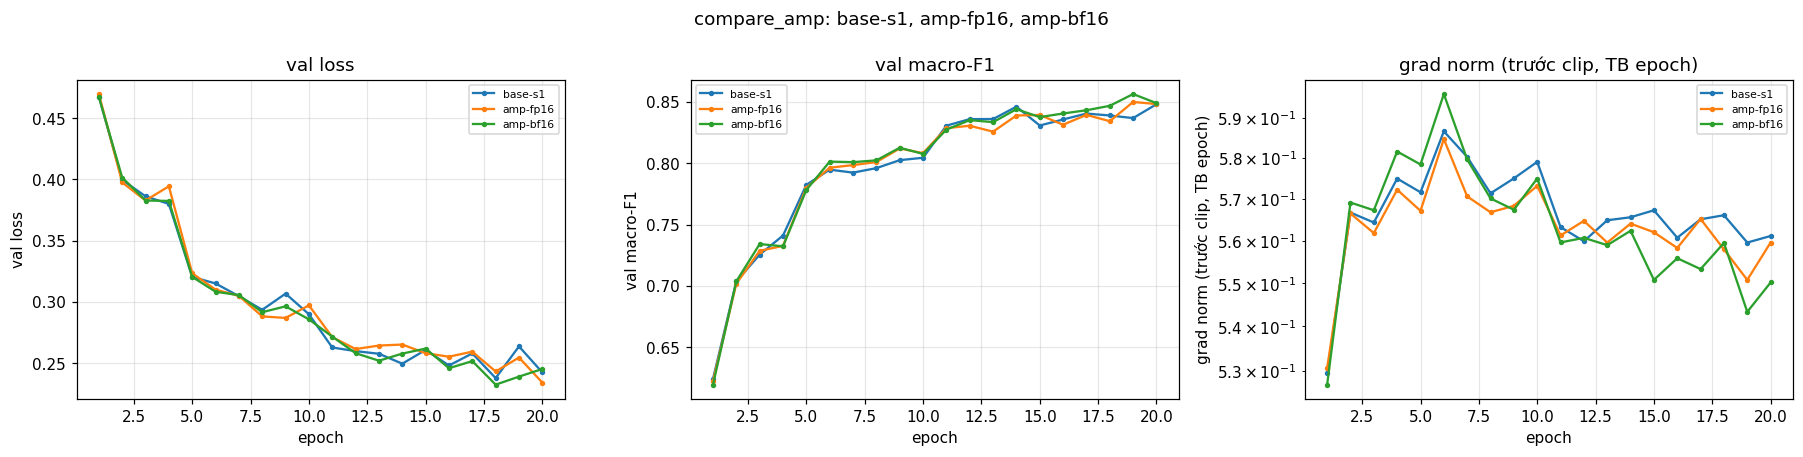

,optimizer,lr,wd,batch,hidden,dropout,clip,prec,init,loss,...,best_val_loss,final_train,final_val,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1 vs base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.1,0.0,512,256-128,0.0,None,fp32,he,ce,...,0.237924,0.216433,0.242554,0.905381,0.839036,1.293512,175.578613,N,-0.014475,Không
amp-fp16,sgd_momentum,0.1,0.0,512,256-128,0.0,None,fp16,he,ce,...,0.234278,0.207723,0.234278,0.905768,0.848360,1.776422,175.577637,N,-0.005150,Không
amp-bf16,sgd_momentum,0.1,0.0,512,256-128,0.0,None,bf16,he,ce,...,0.232563,0.221258,0.245352,0.906220,0.846920,1.525641,175.576660,N,-0.006591,Không


In [14]:
print("bỏ qua:", {k: v for k, v in runner.skipped.items() if k.startswith("amp")} or "không")
show(["base-s1", "amp-*"], "amp")

**Đối chiếu (tự viết):** ...

### Chủ đề 7 — Khởi tạo tham số
`zeros`, `normal` (std 0.01), `xavier` (`xavier_normal_`: Var = 2/(n_in+n_out)), `he` (baseline: Var = 2/n_in), `default` (mặc định
`nn.Linear`: kaiming_uniform với a=√5, Var ≈ 1/(3·n_in)). Bias = 0 (trừ `default`). Std kích hoạt sau mỗi ReLU ở bước 0 (một lô val)
cho M-base và cho một mạng sâu 20 lớp ẩn 256 (chỉ để quan sát, không huấn luyện).

**Dự đoán trước (tự viết):** (gợi ý: với `zeros`, gradient của các nơ-ron cùng lớp ra sao? ReLU(0) = 0 ...)

,ReLU 1,ReLU 2,logits
zeros,0,0,0
normal,0.02027,0.002152,0.0002715
xavier,0.1628,0.1248,0.1916
he,0.3901,0.3661,0.5773
default,0.1603,0.06776,0.05851


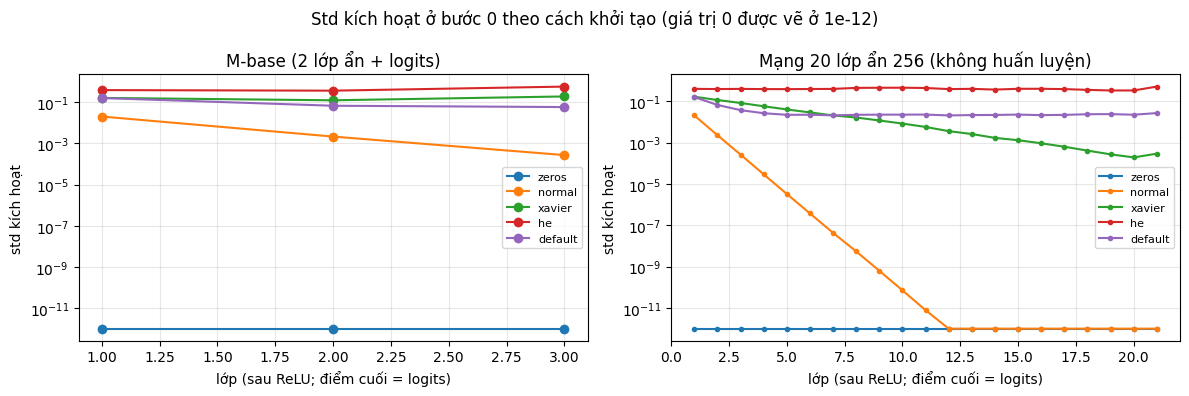

,optimizer,lr,wd,batch,hidden,dropout,clip,prec,init,loss,sched,step0,best_ep,best_val_loss,final_train,final_val,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1 vs base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,18,0.2379,0.2164,0.2426,0.9054,0.8390,1.2935,175.5786,N,-0.0145,Không
init-zeros,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,—,fp32,zeros,ce,—,1.9459,10,1.2052,1.2075,1.2052,0.4876,0.0936,1.3151,175.5786,N,-0.7599,Có
init-normal,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,—,fp32,normal,ce,—,1.9460,20,0.2340,0.2101,0.2340,0.9046,0.8449,1.3179,175.5786,N,-0.0086,Không
init-xavier,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,—,fp32,xavier,ce,—,2.0222,17,0.2317,0.2136,0.2358,0.9072,0.8514,1.3018,175.5786,N,-0.0021,Không
init-default,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,—,fp32,default,ce,—,1.9830,20,0.2348,0.2142,0.2348,0.9058,0.8595,1.2957,175.5786,N,0.0059,Không


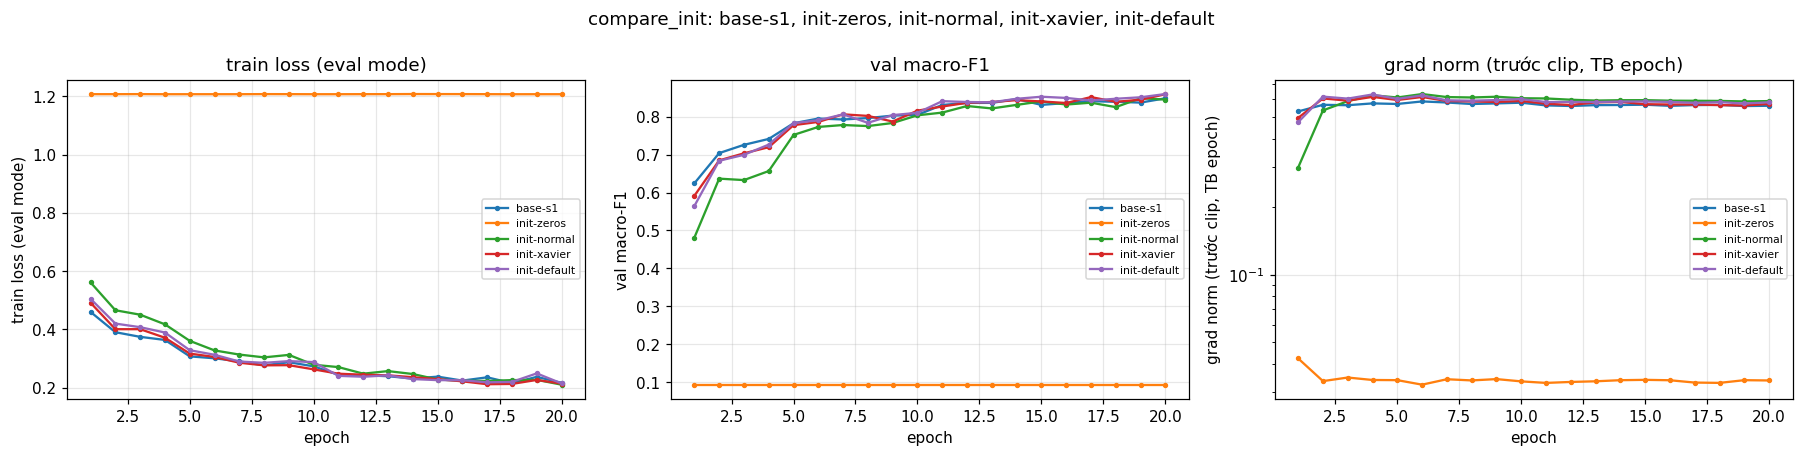

,optimizer,lr,wd,batch,hidden,dropout,clip,prec,init,loss,...,best_val_loss,final_train,final_val,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1 vs base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.1,0.0,512,256-128,0.0,None,fp32,he,ce,...,0.237924,0.216433,0.242554,0.905381,0.839036,1.293512,175.578613,N,-0.014475,Không
init-zeros,sgd_momentum,0.1,0.0,512,256-128,0.0,None,fp32,zeros,ce,...,1.205201,1.207479,1.205219,0.487597,0.093650,1.315082,175.578613,N,-0.759860,Có
init-normal,sgd_momentum,0.1,0.0,512,256-128,0.0,None,fp32,normal,ce,...,0.233970,0.210054,0.233970,0.904628,0.844901,1.317899,175.578613,N,-0.008610,Không
init-xavier,sgd_momentum,0.1,0.0,512,256-128,0.0,None,fp32,xavier,ce,...,0.231742,0.213569,0.235756,0.907231,0.851434,1.301808,175.578613,N,-0.002076,Không
init-default,sgd_momentum,0.1,0.0,512,256-128,0.0,None,fp32,default,ce,...,0.234832,0.214242,0.234832,0.905768,0.859458,1.295655,175.578613,N,0.005948,Không


In [15]:
xb_val = data["X_val"][:4096]
act_rows, deep_rows = {}, {}
for init in ("zeros", "normal", "xavier", "he", "default"):
    set_seed(1)
    act_rows[init] = activation_stats(MLP(hidden=(256, 128), init=init).to(device), xb_val)
    set_seed(1)
    deep_rows[init] = activation_stats(MLP(hidden=(256,) * 20, init=init).to(device), xb_val)
display(pd.DataFrame(act_rows, index=["ReLU 1", "ReLU 2", "logits"]).T.style.format("{:.4g}")
        .set_caption("std kích hoạt ở bước 0, M-base"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for init, stds in act_rows.items():
    axes[0].plot(range(1, len(stds) + 1), np.maximum(stds, 1e-12), "o-", label=init)
for init, stds in deep_rows.items():
    axes[1].plot(range(1, len(stds) + 1), np.maximum(stds, 1e-12), "o-", ms=3, label=init)
for ax, t in zip(axes, ["M-base (2 lớp ẩn + logits)", "Mạng 20 lớp ẩn 256 (không huấn luyện)"]):
    ax.set(yscale="log", xlabel="lớp (sau ReLU; điểm cuối = logits)", ylabel="std kích hoạt", title=t)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.suptitle("Std kích hoạt ở bước 0 theo cách khởi tạo (giá trị 0 được vẽ ở 1e-12)")
fig.tight_layout(); fig.savefig(f"{FIG_DIR}/compare_init_activations.png", dpi=110, bbox_inches="tight"); plt.show()

show(["base-s1", "init-*"], "init")

**Đối chiếu (tự viết):** ...

### Cấu hình cuối (chọn CHỈ bằng val)
Quy tắc (mục `final:` trong `experiments.yaml`): optimizer/lr lấy từ thí nghiệm có val macro-F1 cao nhất trong lưới lr + nhóm optimizer;
kiến trúc / cosine / dropout chỉ thêm nếu thí nghiệm đơn lẻ của nó **vượt baseline hơn 2σ**; huấn luyện `final.epochs` epoch,
giữ epoch có val loss thấp nhất. File nộp là seed đầu tiên.

Cấu hình cuối (40 epoch): optimizer/lr từ opt-adam-lr3e-3
{'optimizer': 'adam', 'lr': 0.003, 'weight_decay': 0.0, 'hidden': (256, 128), 'dropout': 0.0, 'scheduler': None, 'epochs': 40, 'batch': 512}
final val_macro_f1 = 0.8907 ± 0.0018  vs baseline 0.8535 ± 0.0126


,optimizer,lr,wd,batch,hidden,dropout,clip,prec,init,loss,sched,step0,best_ep,best_val_loss,final_train,final_val,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1 vs base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,18,0.2379,0.2164,0.2426,0.9054,0.8390,1.2935,175.5786,N,-0.0145,Không
base-s2,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,1.9782,19,0.2279,0.2067,0.2325,0.9100,0.8601,1.2747,175.5786,N,0.0065,Không
base-s3,sgd_momentum,0.1000,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,1.9005,19,0.2277,0.2135,0.2375,0.9091,0.8614,1.2532,175.5786,N,0.0079,Không
final-s1,adam,0.0030,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,2.2691,38,0.1838,0.1468,0.1882,0.9285,0.8894,1.4589,175.7617,N,0.0359,Có
final-s2,adam,0.0030,0.0000,512,256-128,0.0000,—,fp32,he,ce,—,1.9782,39,0.1794,0.1515,0.1916,0.9311,0.8920,1.4481,175.7617,N,0.0385,Có


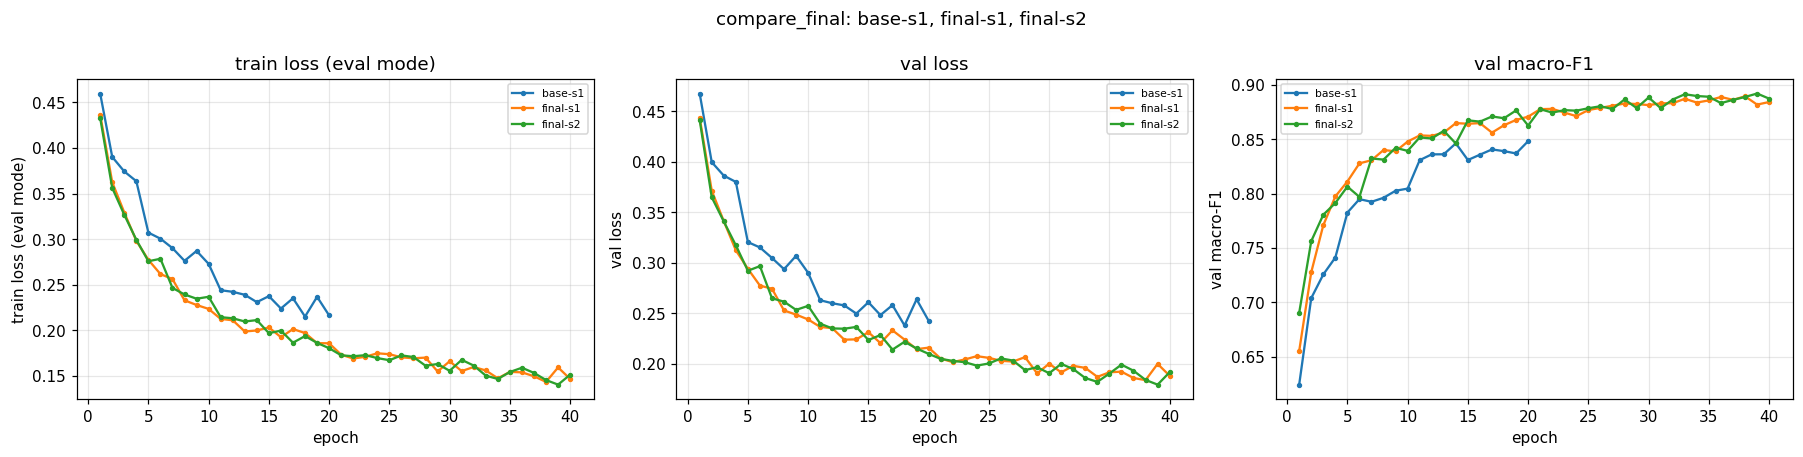

,optimizer,lr,wd,batch,hidden,dropout,clip,prec,init,loss,...,best_val_loss,final_train,final_val,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1 vs base,vượt 2σ?
exp_id,,,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.100,0.0,512,256-128,0.0,None,fp32,he,ce,...,0.237924,0.216433,0.242554,0.905381,0.839036,1.293512,175.578613,N,-0.014475,Không
base-s2,sgd_momentum,0.100,0.0,512,256-128,0.0,None,fp32,he,ce,...,0.227854,0.206715,0.232547,0.909985,0.860050,1.274712,175.578613,N,0.006540,Không
base-s3,sgd_momentum,0.100,0.0,512,256-128,0.0,None,fp32,he,ce,...,0.227659,0.213543,0.237520,0.909103,0.861445,1.253234,175.578613,N,0.007935,Không
final-s1,adam,0.003,0.0,512,256-128,0.0,None,fp32,he,ce,...,0.183817,0.146772,0.188173,0.928530,0.889429,1.458878,175.761719,N,0.035919,Có
final-s2,adam,0.003,0.0,512,256-128,0.0,None,fp32,he,ce,...,0.179360,0.151489,0.191645,0.931133,0.892027,1.448089,175.761719,N,0.038516,Có


In [16]:
print(runner.final_desc)
c = RESULTS[final_ids[0]]["cfg"]
print({k: c[k] for k in ("optimizer", "lr", "weight_decay", "hidden", "dropout", "scheduler", "epochs", "batch")})
ff = np.array([RESULTS[e]["summary"]["val_macro_f1"] for e in final_ids])
print(f"final val_macro_f1 = {ff.mean():.4f}" + (f" ± {ff.std(ddof=1):.4f}" if len(ff) > 1 else "") +
      f"  vs baseline {NOISE['mean']:.4f} ± {NOISE['std']:.4f}")
show(base_ids + final_ids, "final")

**Nhận xét cấu hình cuối (tự viết):** ...

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
Cấu hình đã chọn ở trên **chỉ bằng val**. Giờ mới dự đoán trên toàn bộ eval (eval mode, trọng số ở epoch có val loss thấp nhất)
và chấm bằng đúng `scripts/evaluate.py`. Chỉ làm cho baseline (`base-s1`) và cấu hình cuối (`final-s<seed đầu>`).

In [17]:
SUBMIT_ID = final_ids[0]
os.makedirs(f"{OUT_DIR}/eval_baseline", exist_ok=True)
print("=== Baseline (base-s1) ===")
EVAL_BASE = final_eval(RESULTS["base-s1"]["cfg"], RESULTS["base-s1"], data,
                       f"{OUT_DIR}/eval_baseline/predictions_baseline.csv", repo_root=str(REPO_ROOT),
                       out_json=f"{OUT_DIR}/eval_baseline/eval_result_baseline.json")
print(f"=== Cấu hình cuối ({SUBMIT_ID}) -> file nộp ===")
EVAL_FINAL = final_eval(RESULTS[SUBMIT_ID]["cfg"], RESULTS[SUBMIT_ID], data,
                        f"{OUT_DIR}/predictions_eval.csv", repo_root=str(REPO_ROOT),
                        out_json=f"{OUT_DIR}/eval_result.json")
print(f"baseline: eval acc {EVAL_BASE['accuracy']:.4f}, macro-F1 {EVAL_BASE['macro_f1']:.4f}")
print(f"final   : eval acc {EVAL_FINAL['accuracy']:.4f}, macro-F1 {EVAL_FINAL['macro_f1']:.4f}  "
      f"(Δ = {EVAL_FINAL['macro_f1'] - EVAL_BASE['macro_f1']:+.4f})")
for e, ev in [("base-s1", EVAL_BASE), (SUBMIT_ID, EVAL_FINAL)]:
    print(f"{e}: val F1 {RESULTS[e]['summary']['val_macro_f1']:.4f} vs eval F1 {ev['macro_f1']:.4f}")

=== Baseline (base-s1) ===
đã ghi /content/K4-Track4-Day1-Neuralnetwork/submission_2A202602723/eval_baseline/predictions_baseline.csv (116,203 dòng)
n_eval = 116203
accuracy = 0.9033
macro_f1 = 0.8410   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9016  0.9029  0.9022
  1    56661     0.9093  0.9304  0.9197
  2     7151     0.8972  0.8839  0.8905
  3      549     0.7618  0.7923  0.7768
  4     1899     0.8161  0.6403  0.7176
  5     3473     0.8489  0.7328  0.7866
  6     4102     0.9436  0.8484  0.8935

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  38255   3897     0    0    23     5   188
1   3557  52719    84    1   191    89    20
2      4    359  6321   88    48   331     0
3      0      0    92  435     0    22     0
4     64    600    13    0  1216     6     0
5      9    325   535   47    12  2545     0
6    543     79     0    0     0     0  3480

đã ghi /content/K4-Track4-Day1-Neuralnetwork/submissi

,support,precision,recall,f1,train_count,f1_baseline,Δf1
cls,,,,,,,
0,42368,0.9276,0.9203,0.9239,135578,0.9022,+0.0217
1,56661,0.9356,0.9424,0.9390,181312,0.9197,+0.0192
2,7151,0.9266,0.9280,0.9273,22882,0.8905,+0.0367
3,549,0.8611,0.8015,0.8302,1759,0.7768,+0.0534
4,1899,0.8745,0.7667,0.8171,6075,0.7176,+0.0994
5,3473,0.8483,0.8889,0.8681,11115,0.7866,+0.0815
6,4102,0.9291,0.9322,0.9306,13126,0.8935,+0.0372


,đoán 0,đoán 1,đoán 2,đoán 3,đoán 4,đoán 5,đoán 6
thật 0,38990,3084,4,0,22,11,257
thật 1,2743,53398,163,0,177,145,35
thật 2,3,117,6636,52,8,335,0
thật 3,0,0,65,440,0,44,0
thật 4,61,348,17,0,1456,17,0
thật 5,5,83,277,19,2,3087,0
thật 6,232,46,0,0,0,0,3824


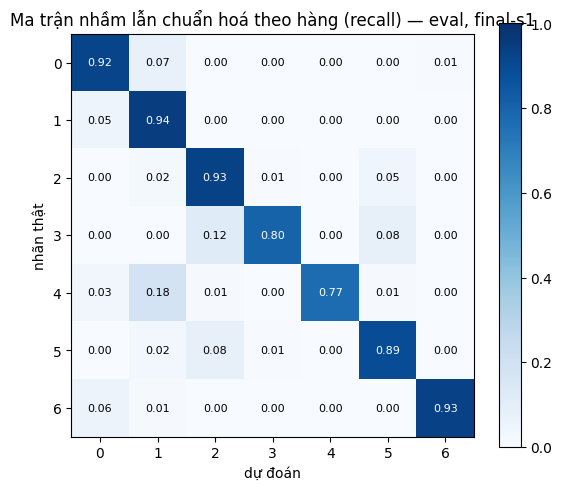

lớp F1 thấp nhất: 4 (F1 0.8171, 6,075 mẫu train); hay bị đoán nhầm thành lớp 1 (348 / 1899 mẫu)
5 cặp nhầm nhiều nhất (thật -> đoán: số mẫu): [(0, 1, 3084), (1, 0, 2743), (4, 1, 348), (2, 5, 335), (5, 2, 277)]


In [18]:
# Phân tích lỗi theo lớp trên eval
n_train_cls = np.bincount(data["y_tr"].cpu().numpy(), minlength=7)
pc = pd.DataFrame(EVAL_FINAL["per_class"]).set_index("cls")
pc["train_count"] = n_train_cls
pc["f1_baseline"] = [c["f1"] for c in EVAL_BASE["per_class"]]
pc["Δf1"] = pc["f1"] - pc["f1_baseline"]
display(pc.style.format({"precision": "{:.4f}", "recall": "{:.4f}", "f1": "{:.4f}", "f1_baseline": "{:.4f}", "Δf1": "{:+.4f}"})
        .set_caption(f"Theo lớp trên eval — {SUBMIT_ID} (nhãn gốc = cls + 1)"))

cm = np.array(EVAL_FINAL["confusion_matrix"])
cm_norm = cm / cm.sum(1, keepdims=True)
display(pd.DataFrame(cm, index=[f"thật {c}" for c in range(7)], columns=[f"đoán {c}" for c in range(7)]))
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
for i in range(7):
    for j in range(7):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if cm_norm[i, j] > 0.5 else "black")
ax.set(xticks=range(7), yticks=range(7), xlabel="dự đoán", ylabel="nhãn thật",
       title=f"Ma trận nhầm lẫn chuẩn hoá theo hàng (recall) — eval, {SUBMIT_ID}")
fig.colorbar(im); plt.show()

off = cm.copy(); np.fill_diagonal(off, 0)
hardest = int(pc["f1"].idxmin())
print(f"lớp F1 thấp nhất: {hardest} (F1 {pc.loc[hardest, 'f1']:.4f}, {n_train_cls[hardest]:,} mẫu train); "
      f"hay bị đoán nhầm thành lớp {int(off[hardest].argmax())} ({off[hardest].max()} / {cm[hardest].sum()} mẫu)")
top = np.dstack(np.unravel_index(np.argsort(off.ravel())[::-1][:5], off.shape))[0]
print("5 cặp nhầm nhiều nhất (thật -> đoán: số mẫu):", [(int(i), int(j), int(off[i, j])) for i, j in top])

**Phân tích lỗi (tự viết):** lớp khó nhất ..., nhầm với lớp ..., vì sao (số mẫu, đặc trưng tương đồng) ...

In [19]:
# Bảng experiments.xlsx: mỗi exp_id đã chạy là một dòng (theo thứ tự chạy); eval chỉ cho base-s1 và cấu hình cuối
eval_of = {"base-s1": EVAL_BASE, SUBMIT_ID: EVAL_FINAL}
note_of = {"base-s1": "baseline dùng để chấm eval", SUBMIT_ID: "cấu hình cuối, file predictions_eval.csv"}
rows = [to_row(r, eval_scores=eval_of.get(e), notes=note_of.get(e, "")) for e, r in RESULTS.items()]
write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx", seed_ids=base_ids)
display(pd.DataFrame(rows).set_index("exp_id")[["group", "optimizer", "lr", "val_acc", "val_macro_f1", "eval_acc", "eval_macro_f1", "diverged"]])
print(f"đã ghi {OUT_DIR}/experiments.xlsx ({len(rows)} dòng) — mở bằng Excel/LibreOffice để các cột công thức tự tính")

,group,optimizer,lr,val_acc,val_macro_f1,eval_acc,eval_macro_f1,diverged
exp_id,,,,,,,,
lr-sgdm-0.003,hparam,SGD+momentum,0.0030,0.825015,0.664664,NaN,NaN,N
lr-sgdm-0.01,hparam,SGD+momentum,0.0100,0.874669,0.761253,NaN,NaN,N
lr-sgdm-0.03,hparam,SGD+momentum,0.0300,0.892139,0.816958,NaN,NaN,N
lr-sgdm-0.1,hparam,SGD+momentum,0.1000,0.905381,0.839036,NaN,NaN,N
base-s1,baseline,SGD+momentum,0.1000,0.905381,0.839036,0.903342,0.840992,N
base-s2,baseline,SGD+momentum,0.1000,0.909985,0.860050,NaN,NaN,N
base-s3,baseline,SGD+momentum,0.1000,0.909103,0.861445,NaN,NaN,N
loss-mse,loss,SGD+momentum,0.1000,0.870506,0.727665,NaN,NaN,N
loss-mse-lrx10,loss,SGD+momentum,1.0000,0.795615,0.599100,NaN,NaN,N


đã ghi /content/K4-Track4-Day1-Neuralnetwork/submission_2A202602723/experiments.xlsx (39 dòng) — mở bằng Excel/LibreOffice để các cột công thức tự tính


In [20]:
# Kiểm tra nhanh trước khi nộp (README mục 6.4)
figs = {p.stem for p in Path(FIG_DIR).glob("*.png") if not p.stem.startswith("compare_")}
ids = {r["exp_id"] for r in rows}
print("số dòng bảng:", len(ids), "| số ảnh figures/<exp_id>.png:", len(figs))
assert figs == ids, f"thiếu ảnh: {ids - figs}, ảnh thừa: {figs - ids}"
for f in ["experiments.xlsx", "predictions_eval.csv", "eval_result.json", "code/lab.ipynb"]:
    assert (SUB_DIR / f).exists(), f
pred = pd.read_csv(SUB_DIR / "predictions_eval.csv")
assert list(pred.columns) == ["row_id", "pred"] and len(pred) == 116_203 and pred["row_id"].is_unique
leftover = [p.name for p in CODE_DIR.glob("*.py") if "NotImplementedError" in p.read_text(encoding="utf-8")]
assert not leftover, leftover
print("OK. Còn lại phần tự làm: viết REPORT.md, nhận xét trong notebook và sheet Summary; lưu notebook (có output) vào",
      CODE_DIR / "lab.ipynb")
print("Lưu ý: không nộp thư mục eval_baseline/ nếu không cần; checkpoints nằm ở", CKPT_DIR, "(ngoài thư mục nộp)")

số dòng bảng: 39 | số ảnh figures/<exp_id>.png: 39
OK. Còn lại phần tự làm: viết REPORT.md, nhận xét trong notebook và sheet Summary; lưu notebook (có output) vào /content/K4-Track4-Day1-Neuralnetwork/submission_2A202602723/code/lab.ipynb
Lưu ý: không nộp thư mục eval_baseline/ nếu không cần; checkpoints nằm ở /content/K4-Track4-Day1-Neuralnetwork/checkpoints/submission_2A202602723 (ngoài thư mục nộp)
